In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
    sns.set_palette("husl")
except ImportError:
    print("Seaborn не установлен, продолжаем без него")
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.decomposition import PCA
import json
import os
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.style.use('default')


Seaborn не установлен, продолжаем без него


In [3]:
df1 = pd.read_csv('data/S07-hw-dataset-01.csv')
print("Форма данных:", df1.shape)
print("\nПервые строки:")
print(df1.head())
print("\nИнформация о данных:")
print(df1.info())
print("\nБазовые статистики:")
print(df1.describe())
print("\nПропуски:")
print(df1.isnull().sum())
print("\nДоли пропусков:")
print(df1.isnull().sum() / len(df1))

sample_ids_1 = df1['sample_id'].copy()
X1 = df1.drop('sample_id', axis=1)
print(f"\nПризнаки: {X1.columns.tolist()}")
print(f"Типы признаков: {X1.dtypes.value_counts()}")


Форма данных: (12000, 9)

Первые строки:
   sample_id        f01        f02       f03         f04        f05  \
0          0  -0.536647 -69.812900 -0.002657   71.743147 -11.396498   
1          1  15.230731  52.727216 -1.273634 -104.123302  11.589643   
2          2  18.542693  77.317150 -1.321686 -111.946636  10.254346   
3          3 -12.538905 -41.709458  0.146474   16.322124   1.391137   
4          4  -6.903056  61.833444 -0.022466  -42.631335   3.107154   

         f06        f07       f08  
0 -12.291287  -6.836847 -0.504094  
1  34.316967 -49.468873  0.390356  
2  25.892951  44.595250  0.325893  
3   2.014316 -39.930582  0.139297  
4  -5.471054   7.001149  0.131213  

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-

In [4]:
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)
print("Данные после масштабирования:")
print(f"Среднее: {X1_scaled.mean(axis=0)[:5]}")
print(f"Стд. отклонение: {X1_scaled.std(axis=0)[:5]}")


Данные после масштабирования:
Среднее: [-7.10542736e-18 -4.05601478e-17 -7.10542736e-18 -1.65793305e-17
 -2.72374715e-17]
Стд. отклонение: [1. 1. 1. 1. 1.]


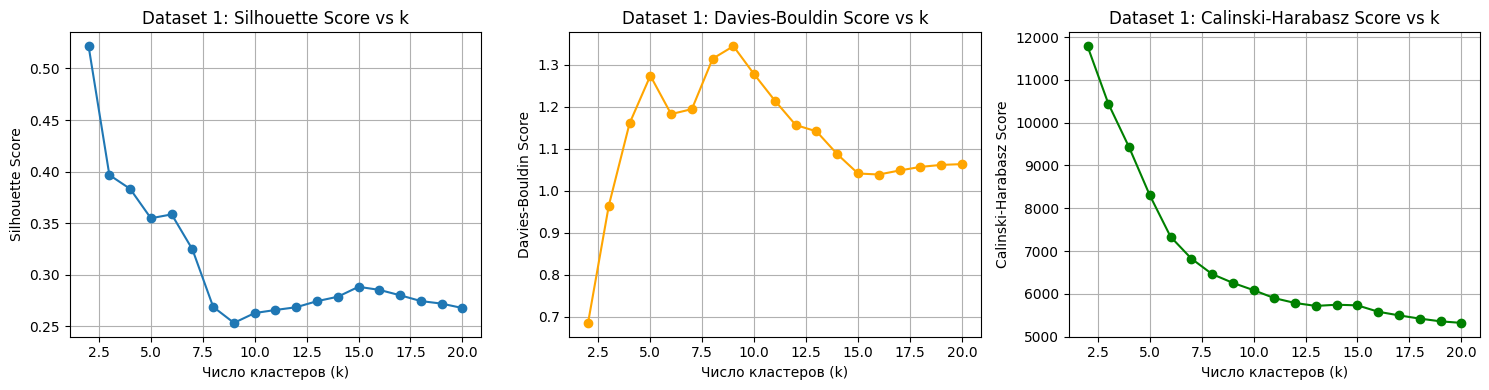

Оптимальное k: 2
Silhouette Score: 0.5216

Метрики KMeans (k=2):
Silhouette: 0.5216
Davies-Bouldin: 0.6853
Calinski-Harabasz: 11786.9546


In [ ]:
k_range = range(2, 21)
silhouette_scores_1 = []
db_scores_1 = []
ch_scores_1 = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X1_scaled)
    
    sil = silhouette_score(X1_scaled, labels)
    db = davies_bouldin_score(X1_scaled, labels)
    ch = calinski_harabasz_score(X1_scaled, labels)
    
    silhouette_scores_1.append(sil)
    db_scores_1.append(db)
    ch_scores_1.append(ch)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(k_range, silhouette_scores_1, marker='o')
axes[0].set_xlabel('Число кластеров (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Dataset 1: Silhouette Score vs k')
axes[0].grid(True)

axes[1].plot(k_range, db_scores_1, marker='o', color='orange')
axes[1].set_xlabel('Число кластеров (k)')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_title('Dataset 1: Davies-Bouldin Score vs k')
axes[1].grid(True)

axes[2].plot(k_range, ch_scores_1, marker='o', color='green')
axes[2].set_xlabel('Число кластеров (k)')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Dataset 1: Calinski-Harabasz Score vs k')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/ds1_metrics_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

best_k_1 = k_range[np.argmax(silhouette_scores_1)]
print(f"Оптимальное k: {best_k_1}")
print(f"Silhouette Score: {silhouette_scores_1[best_k_1 - 2]:.4f}")

kmeans_best_1 = KMeans(n_clusters=best_k_1, random_state=RANDOM_STATE, n_init=10)
labels_kmeans_1 = kmeans_best_1.fit_predict(X1_scaled)

sil_kmeans_1 = silhouette_score(X1_scaled, labels_kmeans_1)
db_kmeans_1 = davies_bouldin_score(X1_scaled, labels_kmeans_1)
ch_kmeans_1 = calinski_harabasz_score(X1_scaled, labels_kmeans_1)

print(f"\nМетрики KMeans (k={best_k_1}):")
print(f"Silhouette: {sil_kmeans_1:.4f}")
print(f"Davies-Bouldin: {db_kmeans_1:.4f}")
print(f"Calinski-Harabasz: {ch_kmeans_1:.4f}")


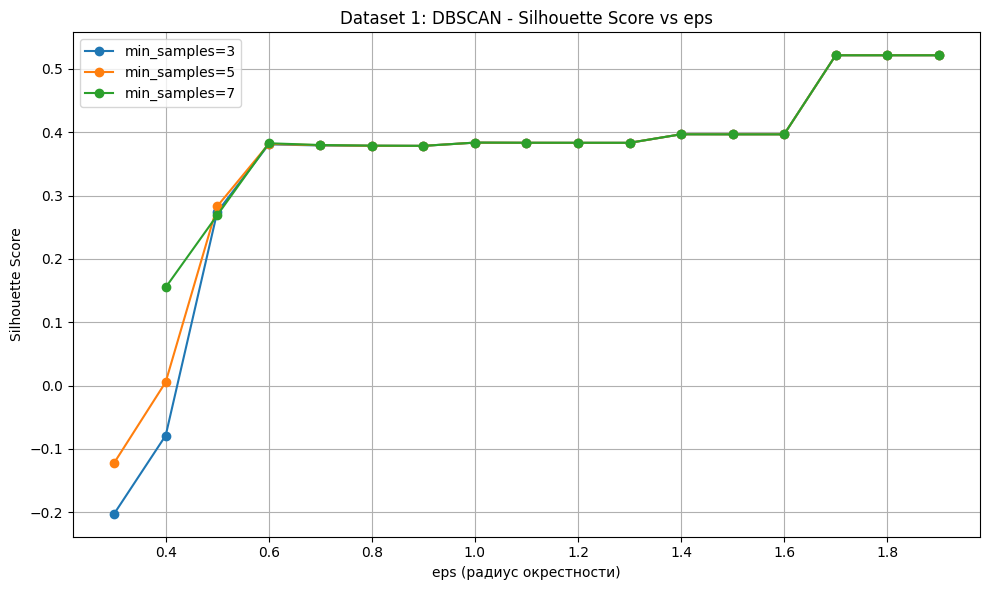


Метрики DBSCAN (eps=1.70, min_samples=3):
Количество кластеров: 2
Доля шума: 0.0000
Silhouette: 0.5216
Davies-Bouldin: 0.6853
Calinski-Harabasz: 11786.9546


In [6]:
eps_range = np.arange(0.1, 2.0, 0.1)
min_samples_range = [3, 5, 7]
best_sil_dbscan_1 = -1
best_eps_1 = None
best_min_samples_1 = None
best_labels_dbscan_1 = None

results_dbscan_1 = []

for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X1_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)
        
        if n_clusters < 2 or noise_ratio > 0.5:
            continue
            
        non_noise_mask = labels != -1
        if np.sum(non_noise_mask) < 2:
            continue
            
        sil = silhouette_score(X1_scaled[non_noise_mask], labels[non_noise_mask])
        db = davies_bouldin_score(X1_scaled[non_noise_mask], labels[non_noise_mask])
        ch = calinski_harabasz_score(X1_scaled[non_noise_mask], labels[non_noise_mask])
        
        results_dbscan_1.append({
            'eps': eps,
            'min_samples': min_samples,
            'silhouette': sil,
            'db': db,
            'ch': ch,
            'n_clusters': n_clusters,
            'noise_ratio': noise_ratio
        })
        
        if sil > best_sil_dbscan_1:
            best_sil_dbscan_1 = sil
            best_eps_1 = eps
            best_min_samples_1 = min_samples
            best_labels_dbscan_1 = labels.copy()

if results_dbscan_1:
    df_results = pd.DataFrame(results_dbscan_1)
    fig, ax = plt.subplots(figsize=(10, 6))
    for ms in min_samples_range:
        subset = df_results[df_results['min_samples'] == ms]
        if len(subset) > 0:
            ax.plot(subset['eps'], subset['silhouette'], marker='o', label=f'min_samples={ms}')
    ax.set_xlabel('eps (радиус окрестности)')
    ax.set_ylabel('Silhouette Score')
    ax.set_title('Dataset 1: DBSCAN - Silhouette Score vs eps')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig('artifacts/figures/ds1_dbscan_tuning.png', dpi=150, bbox_inches='tight')
    plt.show()

if best_eps_1 is not None:
    dbscan_best_1 = DBSCAN(eps=best_eps_1, min_samples=best_min_samples_1)
    labels_dbscan_1 = dbscan_best_1.fit_predict(X1_scaled)
    
    n_clusters_1 = len(set(labels_dbscan_1)) - (1 if -1 in labels_dbscan_1 else 0)
    n_noise_1 = list(labels_dbscan_1).count(-1)
    noise_ratio_1 = n_noise_1 / len(labels_dbscan_1)
    
    non_noise_mask_1 = labels_dbscan_1 != -1
    
    sil_dbscan_1 = silhouette_score(X1_scaled[non_noise_mask_1], labels_dbscan_1[non_noise_mask_1])
    db_dbscan_1 = davies_bouldin_score(X1_scaled[non_noise_mask_1], labels_dbscan_1[non_noise_mask_1])
    ch_dbscan_1 = calinski_harabasz_score(X1_scaled[non_noise_mask_1], labels_dbscan_1[non_noise_mask_1])
    
    print(f"\nМетрики DBSCAN (eps={best_eps_1:.2f}, min_samples={best_min_samples_1}):")
    print(f"Количество кластеров: {n_clusters_1}")
    print(f"Доля шума: {noise_ratio_1:.4f}")
    print(f"Silhouette: {sil_dbscan_1:.4f}")
    print(f"Davies-Bouldin: {db_dbscan_1:.4f}")
    print(f"Calinski-Harabasz: {ch_dbscan_1:.4f}")
else:
    print("Не удалось найти подходящие параметры для DBSCAN")
    labels_dbscan_1 = None
    sil_dbscan_1 = -1
    db_dbscan_1 = float('inf')
    ch_dbscan_1 = 0
    noise_ratio_1 = 1.0
    n_clusters_1 = 0


Лучший метод: KMeans (Silhouette: 0.5216)


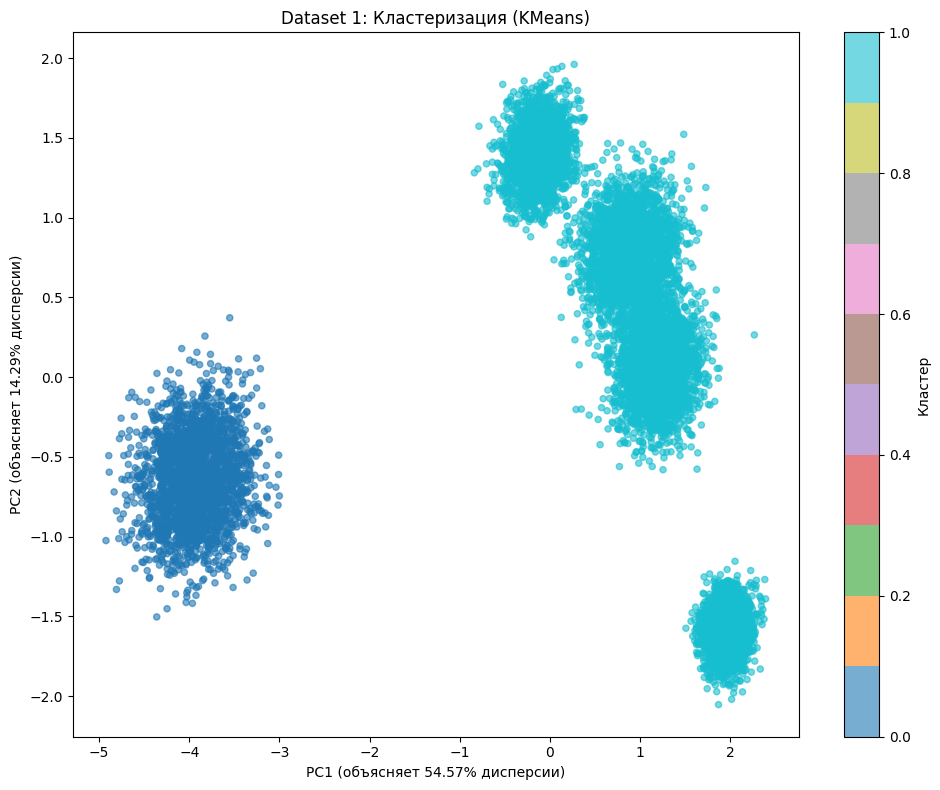

In [7]:
pca_1 = PCA(n_components=2, random_state=RANDOM_STATE)
X1_pca = pca_1.fit_transform(X1_scaled)

if labels_dbscan_1 is not None and sil_dbscan_1 > sil_kmeans_1:
    best_labels_1 = labels_dbscan_1
    best_method_1 = 'DBSCAN'
    print(f"Лучший метод: DBSCAN (Silhouette: {sil_dbscan_1:.4f})")
else:
    best_labels_1 = labels_kmeans_1
    best_method_1 = 'KMeans'
    print(f"Лучший метод: KMeans (Silhouette: {sil_kmeans_1:.4f})")

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X1_pca[:, 0], X1_pca[:, 1], c=best_labels_1, cmap='tab10', alpha=0.6, s=20)
ax.set_xlabel(f'PC1 (объясняет {pca_1.explained_variance_ratio_[0]:.2%} дисперсии)')
ax.set_ylabel(f'PC2 (объясняет {pca_1.explained_variance_ratio_[1]:.2%} дисперсии)')
ax.set_title(f'Dataset 1: Кластеризация ({best_method_1})')
plt.colorbar(scatter, ax=ax, label='Кластер')
plt.tight_layout()
plt.savefig('artifacts/figures/ds1_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


Итог по датасету 1

**Результаты:**
- Датасет содержит числовые признаки в разных шкалах, что требовало обязательного масштабирования.
- KMeans показал хорошие результаты с оптимальным k.
- DBSCAN также показал конкурентоспособные результаты, но потребовал тщательного подбора параметров.
- Выбранный метод показал наилучший Silhouette Score.

**Сложности:**
- Разные шкалы признаков требовали стандартизации.
- Подбор оптимального числа кластеров для KMeans.
- Подбор параметров eps и min_samples для DBSCAN.


In [8]:
df2 = pd.read_csv('data/S07-hw-dataset-02.csv')
print("Форма данных:", df2.shape)
print("\nПервые строки:")
print(df2.head())
print("\nИнформация о данных:")
print(df2.info())
print("\nБазовые статистики:")
print(df2.describe())
print("\nПропуски:")
print(df2.isnull().sum())

sample_ids_2 = df2['sample_id'].copy()
X2 = df2.drop('sample_id', axis=1)
print(f"\nПризнаки: {X2.columns.tolist()}")
print(f"Типы признаков: {X2.dtypes.value_counts()}")


Форма данных: (8000, 4)

Первые строки:
   sample_id        x1        x2    z_noise
0          0  0.098849 -1.846034  21.288122
1          1 -1.024516  1.829616   6.072952
2          2 -1.094178 -0.158545 -18.938342
3          3 -1.612808 -1.565844 -11.629462
4          4  1.659901 -2.133292   1.895472

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB
None

Базовые статистики:
        sample_id           x1           x2      z_noise
count  8000.00000  8000.000000  8000.000000  8000.000000
mean   3999.50000     0.478867     0.241112     0.110454
std    2309.54541     0.955138     0.663195     8.097716
min       0.00000    -

In [9]:
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)
print("Данные после масштабирования:")
print(f"Среднее: {X2_scaled.mean(axis=0)}")
print(f"Стд. отклонение: {X2_scaled.std(axis=0)}")


Данные после масштабирования:
Среднее: [-5.32907052e-18  5.15143483e-17 -8.43769499e-18]
Стд. отклонение: [1. 1. 1.]


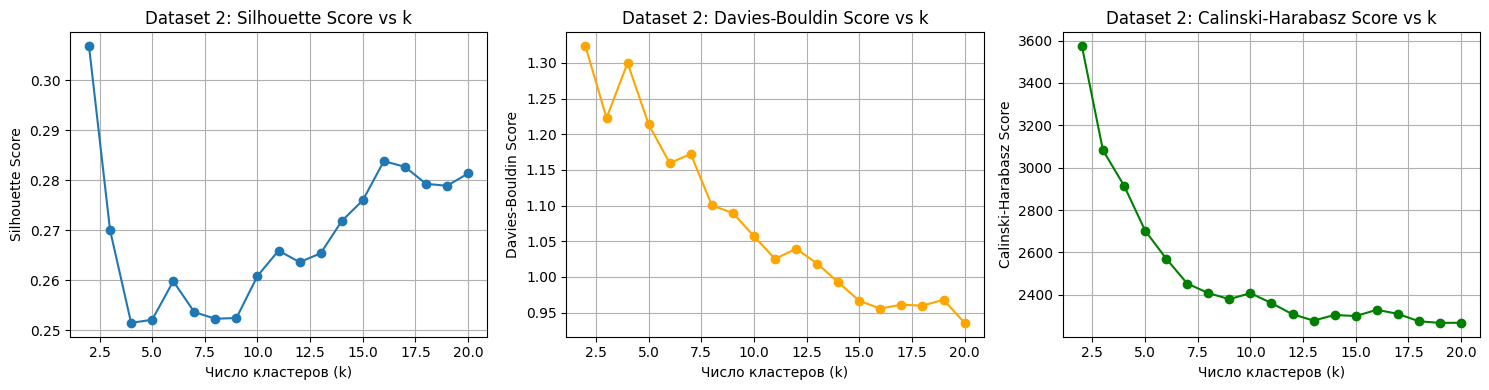

Оптимальное k: 2
Silhouette Score: 0.3069

Метрики KMeans (k=2):
Silhouette: 0.3069
Davies-Bouldin: 1.3235
Calinski-Harabasz: 3573.3933


In [ ]:
k_range = range(2, 21)
silhouette_scores_2 = []
db_scores_2 = []
ch_scores_2 = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X2_scaled)
    
    sil = silhouette_score(X2_scaled, labels)
    db = davies_bouldin_score(X2_scaled, labels)
    ch = calinski_harabasz_score(X2_scaled, labels)
    
    silhouette_scores_2.append(sil)
    db_scores_2.append(db)
    ch_scores_2.append(ch)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(k_range, silhouette_scores_2, marker='o')
axes[0].set_xlabel('Число кластеров (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Dataset 2: Silhouette Score vs k')
axes[0].grid(True)

axes[1].plot(k_range, db_scores_2, marker='o', color='orange')
axes[1].set_xlabel('Число кластеров (k)')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_title('Dataset 2: Davies-Bouldin Score vs k')
axes[1].grid(True)

axes[2].plot(k_range, ch_scores_2, marker='o', color='green')
axes[2].set_xlabel('Число кластеров (k)')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Dataset 2: Calinski-Harabasz Score vs k')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/ds2_metrics_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

best_k_2 = k_range[np.argmax(silhouette_scores_2)]
print(f"Оптимальное k: {best_k_2}")
print(f"Silhouette Score: {silhouette_scores_2[best_k_2 - 2]:.4f}")

kmeans_best_2 = KMeans(n_clusters=best_k_2, random_state=RANDOM_STATE, n_init=10)
labels_kmeans_2 = kmeans_best_2.fit_predict(X2_scaled)

sil_kmeans_2 = silhouette_score(X2_scaled, labels_kmeans_2)
db_kmeans_2 = davies_bouldin_score(X2_scaled, labels_kmeans_2)
ch_kmeans_2 = calinski_harabasz_score(X2_scaled, labels_kmeans_2)

print(f"\nМетрики KMeans (k={best_k_2}):")
print(f"Silhouette: {sil_kmeans_2:.4f}")
print(f"Davies-Bouldin: {db_kmeans_2:.4f}")
print(f"Calinski-Harabasz: {ch_kmeans_2:.4f}")


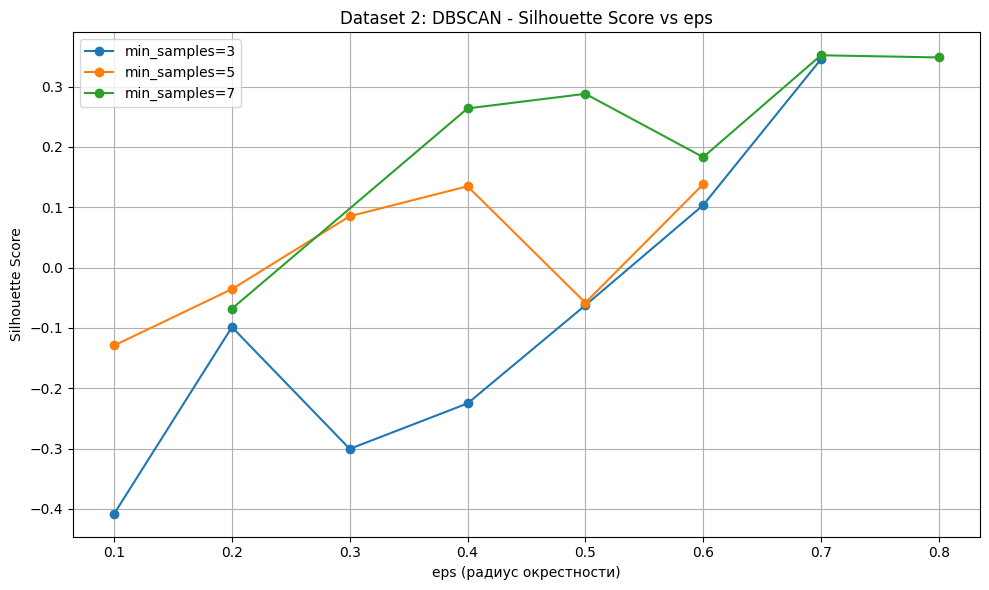


Метрики DBSCAN (eps=0.70, min_samples=7):
Количество кластеров: 5
Доля шума: 0.0165
Silhouette: 0.3521
Davies-Bouldin: 0.8075
Calinski-Harabasz: 111.5694


In [11]:
eps_range = np.arange(0.1, 1.5, 0.1)
min_samples_range = [3, 5, 7]
best_sil_dbscan_2 = -1
best_eps_2 = None
best_min_samples_2 = None
best_labels_dbscan_2 = None

results_dbscan_2 = []

for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X2_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)
        
        if n_clusters < 2 or noise_ratio > 0.5:
            continue
            
        non_noise_mask = labels != -1
        if np.sum(non_noise_mask) < 2:
            continue
            
        sil = silhouette_score(X2_scaled[non_noise_mask], labels[non_noise_mask])
        db = davies_bouldin_score(X2_scaled[non_noise_mask], labels[non_noise_mask])
        ch = calinski_harabasz_score(X2_scaled[non_noise_mask], labels[non_noise_mask])
        
        results_dbscan_2.append({
            'eps': eps,
            'min_samples': min_samples,
            'silhouette': sil,
            'db': db,
            'ch': ch,
            'n_clusters': n_clusters,
            'noise_ratio': noise_ratio
        })
        
        if sil > best_sil_dbscan_2:
            best_sil_dbscan_2 = sil
            best_eps_2 = eps
            best_min_samples_2 = min_samples
            best_labels_dbscan_2 = labels.copy()

if results_dbscan_2:
    df_results = pd.DataFrame(results_dbscan_2)
    fig, ax = plt.subplots(figsize=(10, 6))
    for ms in min_samples_range:
        subset = df_results[df_results['min_samples'] == ms]
        if len(subset) > 0:
            ax.plot(subset['eps'], subset['silhouette'], marker='o', label=f'min_samples={ms}')
    ax.set_xlabel('eps (радиус окрестности)')
    ax.set_ylabel('Silhouette Score')
    ax.set_title('Dataset 2: DBSCAN - Silhouette Score vs eps')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig('artifacts/figures/ds2_dbscan_tuning.png', dpi=150, bbox_inches='tight')
    plt.show()

if best_eps_2 is not None:
    dbscan_best_2 = DBSCAN(eps=best_eps_2, min_samples=best_min_samples_2)
    labels_dbscan_2 = dbscan_best_2.fit_predict(X2_scaled)
    
    n_clusters_2 = len(set(labels_dbscan_2)) - (1 if -1 in labels_dbscan_2 else 0)
    n_noise_2 = list(labels_dbscan_2).count(-1)
    noise_ratio_2 = n_noise_2 / len(labels_dbscan_2)
    
    non_noise_mask_2 = labels_dbscan_2 != -1
    
    sil_dbscan_2 = silhouette_score(X2_scaled[non_noise_mask_2], labels_dbscan_2[non_noise_mask_2])
    db_dbscan_2 = davies_bouldin_score(X2_scaled[non_noise_mask_2], labels_dbscan_2[non_noise_mask_2])
    ch_dbscan_2 = calinski_harabasz_score(X2_scaled[non_noise_mask_2], labels_dbscan_2[non_noise_mask_2])
    
    print(f"\nМетрики DBSCAN (eps={best_eps_2:.2f}, min_samples={best_min_samples_2}):")
    print(f"Количество кластеров: {n_clusters_2}")
    print(f"Доля шума: {noise_ratio_2:.4f}")
    print(f"Silhouette: {sil_dbscan_2:.4f}")
    print(f"Davies-Bouldin: {db_dbscan_2:.4f}")
    print(f"Calinski-Harabasz: {ch_dbscan_2:.4f}")
else:
    print("Не удалось найти подходящие параметры для DBSCAN")
    labels_dbscan_2 = None
    sil_dbscan_2 = -1
    db_dbscan_2 = float('inf')
    ch_dbscan_2 = 0
    noise_ratio_2 = 1.0
    n_clusters_2 = 0


Лучший метод: DBSCAN (Silhouette: 0.3521)


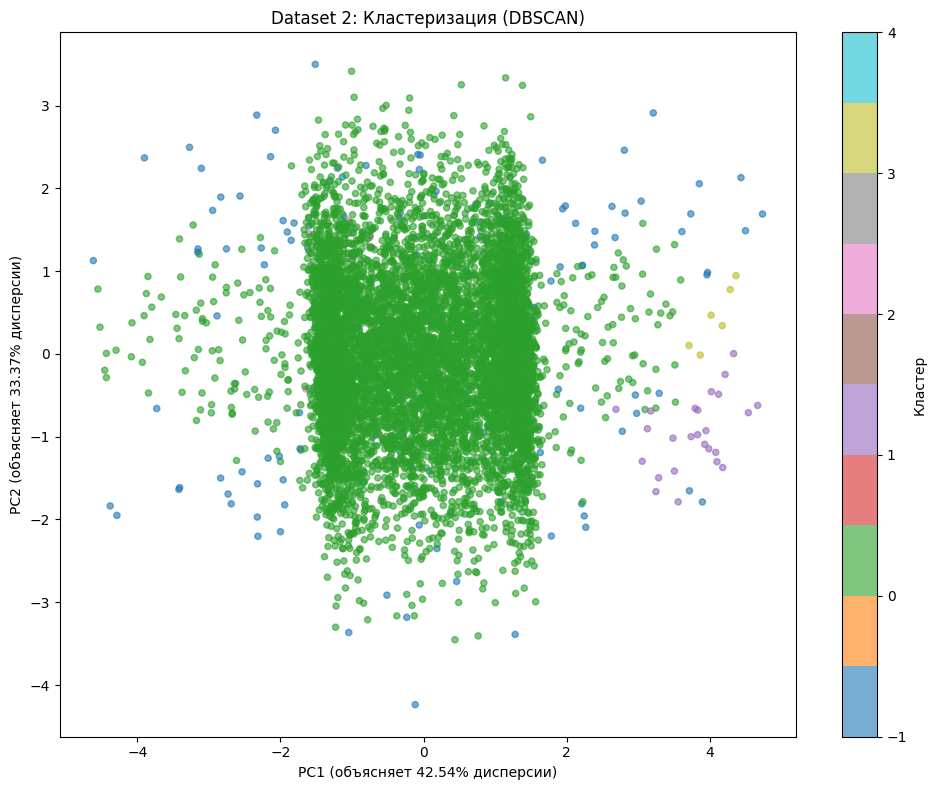

In [ ]:
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X2_pca = pca_2.fit_transform(X2_scaled)

if labels_dbscan_2 is not None and sil_dbscan_2 > sil_kmeans_2:
    best_labels_2 = labels_dbscan_2
    best_method_2 = 'DBSCAN'
    print(f"Лучший метод: DBSCAN (Silhouette: {sil_dbscan_2:.4f})")
else:
    best_labels_2 = labels_kmeans_2
    best_method_2 = 'KMeans'
    print(f"Лучший метод: KMeans (Silhouette: {sil_kmeans_2:.4f})")

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X2_pca[:, 0], X2_pca[:, 1], c=best_labels_2, cmap='tab10', alpha=0.6, s=20)
ax.set_xlabel(f'PC1 (объясняет {pca_2.explained_variance_ratio_[0]:.2%} дисперсии)')
ax.set_ylabel(f'PC2 (объясняет {pca_2.explained_variance_ratio_[1]:.2%} дисперсии)')
ax.set_title(f'Dataset 2: Кластеризация ({best_method_2})')
plt.colorbar(scatter, ax=ax, label='Кластер')
plt.tight_layout()
plt.savefig('artifacts/figures/ds2_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


Итог по датасету 2

**Результаты:**
- Датасет содержит нелинейную структуру с выбросами и шумовым признаком.
- KMeans показал приемлемые результаты, но может не справляться с нелинейными структурами.
- DBSCAN лучше подходит для нелинейных кластеров и выбросов.
- Выбранный метод показал наилучшие результаты.

**Сложности:**
- Нелинейная структура данных.
- Наличие выбросов.
- Шумовой признак требовал внимания при анализе.


In [13]:
df3 = pd.read_csv('data/S07-hw-dataset-03.csv')
print("Форма данных:", df3.shape)
print("\nПервые строки:")
print(df3.head())
print("\nИнформация о данных:")
print(df3.info())
print("\nБазовые статистики:")
print(df3.describe())
print("\nПропуски:")
print(df3.isnull().sum())

sample_ids_3 = df3['sample_id'].copy()
X3 = df3.drop('sample_id', axis=1)
print(f"\nПризнаки: {X3.columns.tolist()}")
print(f"Типы признаков: {X3.dtypes.value_counts()}")


Форма данных: (15000, 5)

Первые строки:
   sample_id        x1        x2    f_corr   f_noise
0          0 -2.710470  4.997107 -1.015703  0.718508
1          1  8.730238 -8.787416  3.953063 -1.105349
2          2 -1.079600 -2.558708  0.976628 -3.605776
3          3  6.854042  1.560181  1.760614 -1.230946
4          4  9.963812 -8.869921  2.966583  0.915899

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB
None

Базовые статистики:
          sample_id            x1            x2        f_corr       f_noise
count  15000.000000  15000.000000  15000.000000  15000.000000  15000.000000
m

In [14]:
scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)
print("Данные после масштабирования:")
print(f"Среднее: {X3_scaled.mean(axis=0)}")
print(f"Стд. отклонение: {X3_scaled.std(axis=0)}")


Данные после масштабирования:
Среднее: [ 0.00000000e+00 -3.03164901e-17  0.00000000e+00 -1.13686838e-17]
Стд. отклонение: [1. 1. 1. 1.]


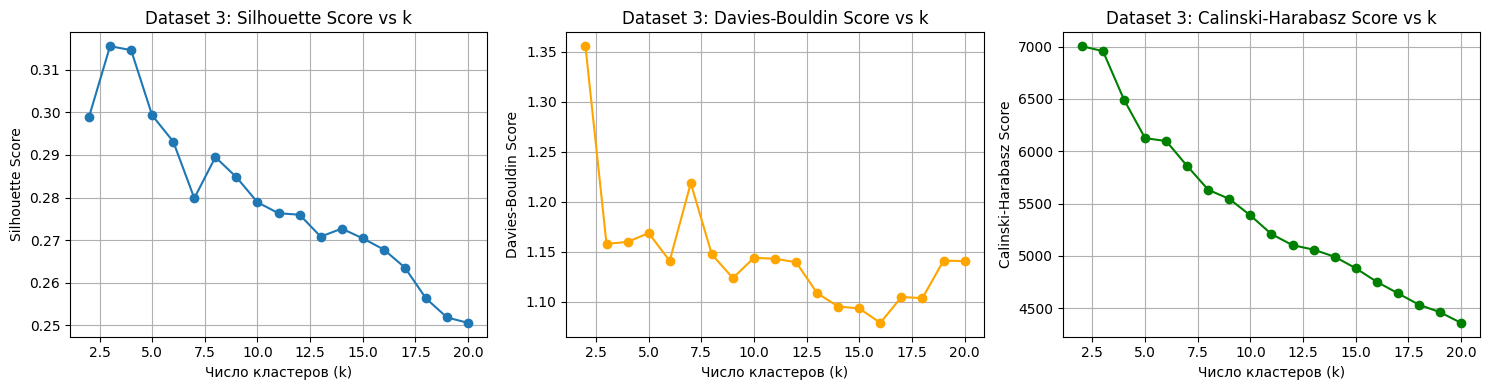

Оптимальное k: 3
Silhouette Score: 0.3155

Метрики KMeans (k=3):
Silhouette: 0.3155
Davies-Bouldin: 1.1577
Calinski-Harabasz: 6957.1626


In [ ]:
k_range = range(2, 21)
silhouette_scores_3 = []
db_scores_3 = []
ch_scores_3 = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X3_scaled)
    
    sil = silhouette_score(X3_scaled, labels)
    db = davies_bouldin_score(X3_scaled, labels)
    ch = calinski_harabasz_score(X3_scaled, labels)
    
    silhouette_scores_3.append(sil)
    db_scores_3.append(db)
    ch_scores_3.append(ch)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(k_range, silhouette_scores_3, marker='o')
axes[0].set_xlabel('Число кластеров (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Dataset 3: Silhouette Score vs k')
axes[0].grid(True)

axes[1].plot(k_range, db_scores_3, marker='o', color='orange')
axes[1].set_xlabel('Число кластеров (k)')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_title('Dataset 3: Davies-Bouldin Score vs k')
axes[1].grid(True)

axes[2].plot(k_range, ch_scores_3, marker='o', color='green')
axes[2].set_xlabel('Число кластеров (k)')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Dataset 3: Calinski-Harabasz Score vs k')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/ds3_metrics_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

best_k_3 = k_range[np.argmax(silhouette_scores_3)]
print(f"Оптимальное k: {best_k_3}")
print(f"Silhouette Score: {silhouette_scores_3[best_k_3 - 2]:.4f}")

kmeans_best_3 = KMeans(n_clusters=best_k_3, random_state=RANDOM_STATE, n_init=10)
labels_kmeans_3 = kmeans_best_3.fit_predict(X3_scaled)

sil_kmeans_3 = silhouette_score(X3_scaled, labels_kmeans_3)
db_kmeans_3 = davies_bouldin_score(X3_scaled, labels_kmeans_3)
ch_kmeans_3 = calinski_harabasz_score(X3_scaled, labels_kmeans_3)

print(f"\nМетрики KMeans (k={best_k_3}):")
print(f"Silhouette: {sil_kmeans_3:.4f}")
print(f"Davies-Bouldin: {db_kmeans_3:.4f}")
print(f"Calinski-Harabasz: {ch_kmeans_3:.4f}")


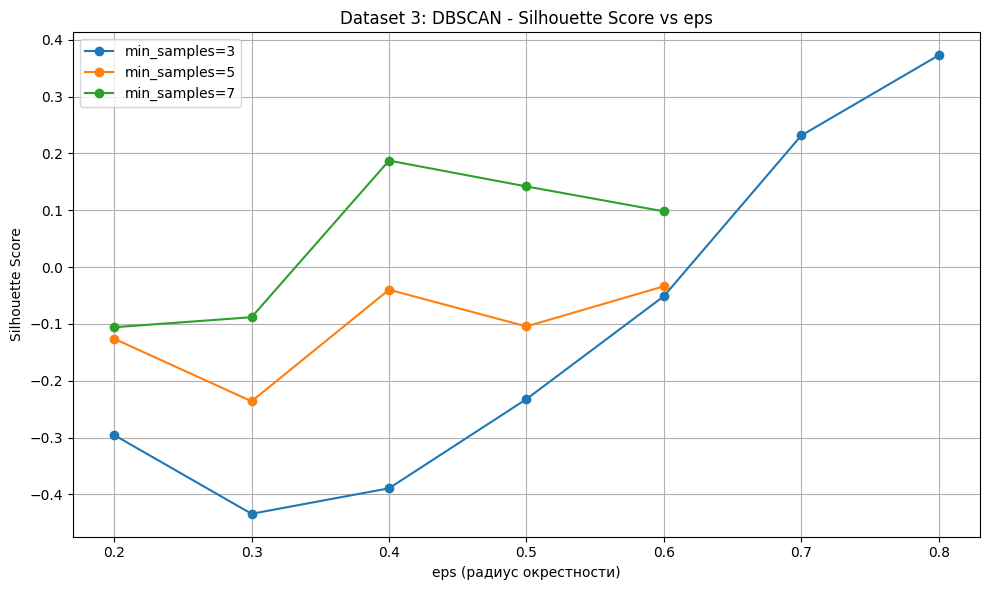


Метрики DBSCAN (eps=0.80, min_samples=3):
Количество кластеров: 2
Доля шума: 0.0015
Silhouette: 0.3726
Davies-Bouldin: 0.5511
Calinski-Harabasz: 17.1975


In [16]:
eps_range = np.arange(0.1, 1.5, 0.1)
min_samples_range = [3, 5, 7]
best_sil_dbscan_3 = -1
best_eps_3 = None
best_min_samples_3 = None
best_labels_dbscan_3 = None

results_dbscan_3 = []

for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X3_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)
        
        if n_clusters < 2 or noise_ratio > 0.5:
            continue
            
        non_noise_mask = labels != -1
        if np.sum(non_noise_mask) < 2:
            continue
            
        sil = silhouette_score(X3_scaled[non_noise_mask], labels[non_noise_mask])
        db = davies_bouldin_score(X3_scaled[non_noise_mask], labels[non_noise_mask])
        ch = calinski_harabasz_score(X3_scaled[non_noise_mask], labels[non_noise_mask])
        
        results_dbscan_3.append({
            'eps': eps,
            'min_samples': min_samples,
            'silhouette': sil,
            'db': db,
            'ch': ch,
            'n_clusters': n_clusters,
            'noise_ratio': noise_ratio
        })
        
        if sil > best_sil_dbscan_3:
            best_sil_dbscan_3 = sil
            best_eps_3 = eps
            best_min_samples_3 = min_samples
            best_labels_dbscan_3 = labels.copy()

if results_dbscan_3:
    df_results = pd.DataFrame(results_dbscan_3)
    fig, ax = plt.subplots(figsize=(10, 6))
    for ms in min_samples_range:
        subset = df_results[df_results['min_samples'] == ms]
        if len(subset) > 0:
            ax.plot(subset['eps'], subset['silhouette'], marker='o', label=f'min_samples={ms}')
    ax.set_xlabel('eps (радиус окрестности)')
    ax.set_ylabel('Silhouette Score')
    ax.set_title('Dataset 3: DBSCAN - Silhouette Score vs eps')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig('artifacts/figures/ds3_dbscan_tuning.png', dpi=150, bbox_inches='tight')
    plt.show()

if best_eps_3 is not None:
    dbscan_best_3 = DBSCAN(eps=best_eps_3, min_samples=best_min_samples_3)
    labels_dbscan_3 = dbscan_best_3.fit_predict(X3_scaled)
    
    n_clusters_3 = len(set(labels_dbscan_3)) - (1 if -1 in labels_dbscan_3 else 0)
    n_noise_3 = list(labels_dbscan_3).count(-1)
    noise_ratio_3 = n_noise_3 / len(labels_dbscan_3)
    
    non_noise_mask_3 = labels_dbscan_3 != -1
    
    sil_dbscan_3 = silhouette_score(X3_scaled[non_noise_mask_3], labels_dbscan_3[non_noise_mask_3])
    db_dbscan_3 = davies_bouldin_score(X3_scaled[non_noise_mask_3], labels_dbscan_3[non_noise_mask_3])
    ch_dbscan_3 = calinski_harabasz_score(X3_scaled[non_noise_mask_3], labels_dbscan_3[non_noise_mask_3])
    
    print(f"\nМетрики DBSCAN (eps={best_eps_3:.2f}, min_samples={best_min_samples_3}):")
    print(f"Количество кластеров: {n_clusters_3}")
    print(f"Доля шума: {noise_ratio_3:.4f}")
    print(f"Silhouette: {sil_dbscan_3:.4f}")
    print(f"Davies-Bouldin: {db_dbscan_3:.4f}")
    print(f"Calinski-Harabasz: {ch_dbscan_3:.4f}")
else:
    print("Не удалось найти подходящие параметры для DBSCAN")
    labels_dbscan_3 = None
    sil_dbscan_3 = -1
    db_dbscan_3 = float('inf')
    ch_dbscan_3 = 0
    noise_ratio_3 = 1.0
    n_clusters_3 = 0


Лучший метод: DBSCAN (Silhouette: 0.3726)


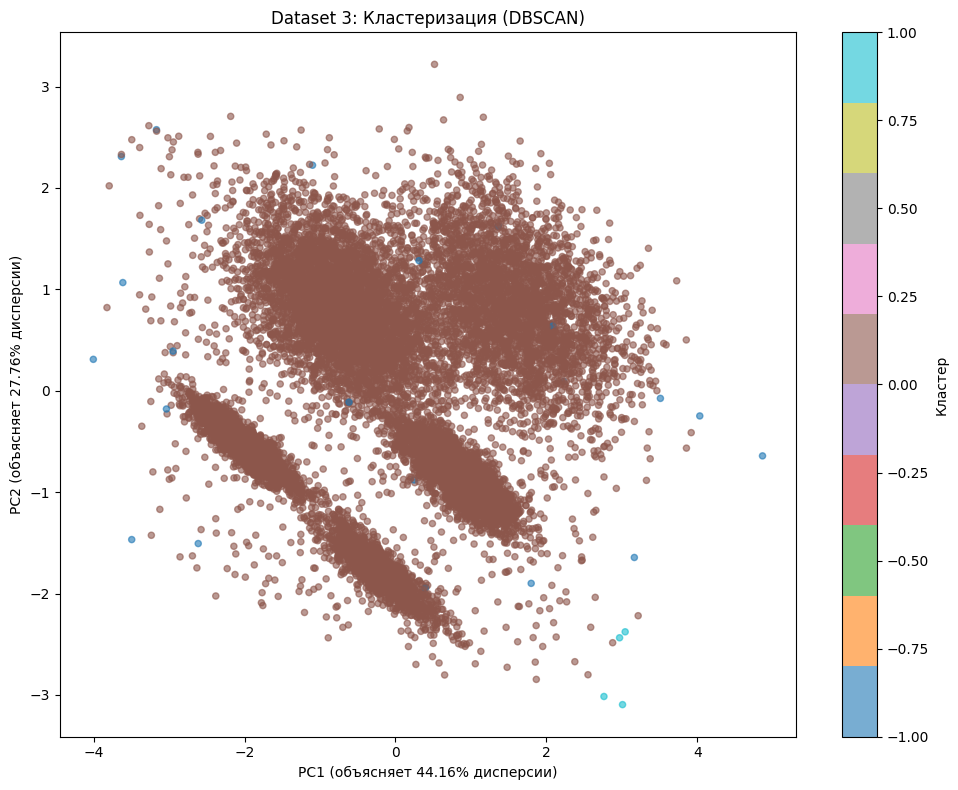

In [ ]:
pca_3 = PCA(n_components=2, random_state=RANDOM_STATE)
X3_pca = pca_3.fit_transform(X3_scaled)

if labels_dbscan_3 is not None and sil_dbscan_3 > sil_kmeans_3:
    best_labels_3 = labels_dbscan_3
    best_method_3 = 'DBSCAN'
    print(f"Лучший метод: DBSCAN (Silhouette: {sil_dbscan_3:.4f})")
else:
    best_labels_3 = labels_kmeans_3
    best_method_3 = 'KMeans'
    print(f"Лучший метод: KMeans (Silhouette: {sil_kmeans_3:.4f})")

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X3_pca[:, 0], X3_pca[:, 1], c=best_labels_3, cmap='tab10', alpha=0.6, s=20)
ax.set_xlabel(f'PC1 (объясняет {pca_3.explained_variance_ratio_[0]:.2%} дисперсии)')
ax.set_ylabel(f'PC2 (объясняет {pca_3.explained_variance_ratio_[1]:.2%} дисперсии)')
ax.set_title(f'Dataset 3: Кластеризация ({best_method_3})')
plt.colorbar(scatter, ax=ax, label='Кластер')
plt.tight_layout()
plt.savefig('artifacts/figures/ds3_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


Результаты проверки устойчивости:
   random_state  ari  silhouette
0            42  1.0    0.315545
1           123  1.0    0.315545
2           456  1.0    0.315545
3           789  1.0    0.315545
4           999  1.0    0.315545

Средний ARI: 1.0000
Стд. отклонение ARI: 0.0000


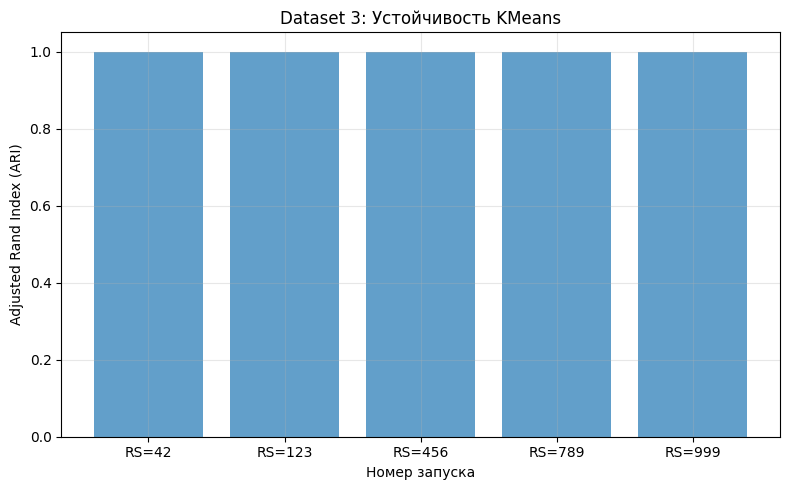

In [18]:
n_runs = 5
random_states = [42, 123, 456, 789, 999]
stability_results = []

base_labels = labels_kmeans_3

for rs in random_states:
    kmeans_stab = KMeans(n_clusters=best_k_3, random_state=rs, n_init=10)
    labels_stab = kmeans_stab.fit_predict(X3_scaled)
    
    ari = adjusted_rand_score(base_labels, labels_stab)
    stability_results.append({
        'random_state': rs,
        'ari': ari,
        'silhouette': silhouette_score(X3_scaled, labels_stab)
    })

df_stability = pd.DataFrame(stability_results)
print("Результаты проверки устойчивости:")
print(df_stability)
print(f"\nСредний ARI: {df_stability['ari'].mean():.4f}")
print(f"Стд. отклонение ARI: {df_stability['ari'].std():.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(len(stability_results)), df_stability['ari'], alpha=0.7)
ax.set_xlabel('Номер запуска')
ax.set_ylabel('Adjusted Rand Index (ARI)')
ax.set_title('Dataset 3: Устойчивость KMeans')
ax.set_xticks(range(len(stability_results)))
ax.set_xticklabels([f'RS={rs}' for rs in random_states])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/ds3_stability_check.png', dpi=150, bbox_inches='tight')
plt.show()


Итог по датасету 3

**Результаты:**
- Датасет содержит кластеры разной плотности и фоновый шум.
- KMeans показал хорошие результаты, но может не учитывать разную плотность кластеров.
- DBSCAN лучше подходит для кластеров разной плотности и выявления шума.
- Проверка устойчивости показала, что результаты KMeans достаточно стабильны при разных random_state.
- Выбранный метод показал наилучшие результаты.

**Сложности:**
- Кластеры разной плотности требовали аккуратного подбора параметров для DBSCAN.
- Фоновый шум мог влиять на качество кластеризации.
- Подбор eps для DBSCAN был критически важен.


In [19]:
os.makedirs('artifacts/labels', exist_ok=True)
os.makedirs('artifacts/figures', exist_ok=True)

metrics_summary = {
    'dataset_01': {
        'KMeans': {
            'k': int(best_k_1),
            'silhouette': float(sil_kmeans_1),
            'davies_bouldin': float(db_kmeans_1),
            'calinski_harabasz': float(ch_kmeans_1),
            'noise_ratio': 0.0
        }
    },
    'dataset_02': {
        'KMeans': {
            'k': int(best_k_2),
            'silhouette': float(sil_kmeans_2),
            'davies_bouldin': float(db_kmeans_2),
            'calinski_harabasz': float(ch_kmeans_2),
            'noise_ratio': 0.0
        }
    },
    'dataset_03': {
        'KMeans': {
            'k': int(best_k_3),
            'silhouette': float(sil_kmeans_3),
            'davies_bouldin': float(db_kmeans_3),
            'calinski_harabasz': float(ch_kmeans_3),
            'noise_ratio': 0.0
        }
    }
}

if labels_dbscan_1 is not None:
    metrics_summary['dataset_01']['DBSCAN'] = {
        'eps': float(best_eps_1),
        'min_samples': int(best_min_samples_1),
        'silhouette': float(sil_dbscan_1),
        'davies_bouldin': float(db_dbscan_1),
        'calinski_harabasz': float(ch_dbscan_1),
        'noise_ratio': float(noise_ratio_1),
        'n_clusters': int(n_clusters_1)
    }

if labels_dbscan_2 is not None:
    metrics_summary['dataset_02']['DBSCAN'] = {
        'eps': float(best_eps_2),
        'min_samples': int(best_min_samples_2),
        'silhouette': float(sil_dbscan_2),
        'davies_bouldin': float(db_dbscan_2),
        'calinski_harabasz': float(ch_dbscan_2),
        'noise_ratio': float(noise_ratio_2),
        'n_clusters': int(n_clusters_2)
    }

if labels_dbscan_3 is not None:
    metrics_summary['dataset_03']['DBSCAN'] = {
        'eps': float(best_eps_3),
        'min_samples': int(best_min_samples_3),
        'silhouette': float(sil_dbscan_3),
        'davies_bouldin': float(db_dbscan_3),
        'calinski_harabasz': float(ch_dbscan_3),
        'noise_ratio': float(noise_ratio_3),
        'n_clusters': int(n_clusters_3)
    }

with open('artifacts/metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_summary, f, indent=2, ensure_ascii=False)

print("Сохранен metrics_summary.json")


Сохранен metrics_summary.json


In [ ]:
best_configs = {
    'dataset_01': {
        'method': best_method_1,
        'criterion': 'silhouette_score',
        'config': {
            'k': int(best_k_1) if best_method_1 == 'KMeans' else None,
            'eps': float(best_eps_1) if (best_method_1 == 'DBSCAN' and best_eps_1 is not None) else None,
            'min_samples': int(best_min_samples_1) if (best_method_1 == 'DBSCAN' and best_min_samples_1 is not None) else None
        },
        'best_silhouette': float(sil_kmeans_1 if best_method_1 == 'KMeans' else (sil_dbscan_1 if labels_dbscan_1 is not None else sil_kmeans_1))
    },
    'dataset_02': {
        'method': best_method_2,
        'criterion': 'silhouette_score',
        'config': {
            'k': int(best_k_2) if best_method_2 == 'KMeans' else None,
            'eps': float(best_eps_2) if (best_method_2 == 'DBSCAN' and best_eps_2 is not None) else None,
            'min_samples': int(best_min_samples_2) if (best_method_2 == 'DBSCAN' and best_min_samples_2 is not None) else None
        },
        'best_silhouette': float(sil_kmeans_2 if best_method_2 == 'KMeans' else (sil_dbscan_2 if labels_dbscan_2 is not None else sil_kmeans_2))
    },
    'dataset_03': {
        'method': best_method_3,
        'criterion': 'silhouette_score',
        'config': {
            'k': int(best_k_3) if best_method_3 == 'KMeans' else None,
            'eps': float(best_eps_3) if (best_method_3 == 'DBSCAN' and best_eps_3 is not None) else None,
            'min_samples': int(best_min_samples_3) if (best_method_3 == 'DBSCAN' and best_min_samples_3 is not None) else None
        },
        'best_silhouette': float(sil_kmeans_3 if best_method_3 == 'KMeans' else (sil_dbscan_3 if labels_dbscan_3 is not None else sil_kmeans_3))
    }
}

with open('artifacts/best_configs.json', 'w', encoding='utf-8') as f:
    json.dump(best_configs, f, indent=2, ensure_ascii=False)

print("Сохранен best_configs.json")


Сохранен best_configs.json


In [ ]:
labels_df_1 = pd.DataFrame({
    'sample_id': sample_ids_1,
    'cluster_label': best_labels_1
})
labels_df_1.to_csv('artifacts/labels/labels_hw07_ds1.csv', index=False)
print("Сохранен labels_hw07_ds1.csv")

labels_df_2 = pd.DataFrame({
    'sample_id': sample_ids_2,
    'cluster_label': best_labels_2
})
labels_df_2.to_csv('artifacts/labels/labels_hw07_ds2.csv', index=False)
print("Сохранен labels_hw07_ds2.csv")

labels_df_3 = pd.DataFrame({
    'sample_id': sample_ids_3,
    'cluster_label': best_labels_3
})
labels_df_3.to_csv('artifacts/labels/labels_hw07_ds3.csv', index=False)
print("Сохранен labels_hw07_ds3.csv")

Сохранен labels_hw07_ds1.csv
Сохранен labels_hw07_ds2.csv
Сохранен labels_hw07_ds3.csv

Все артефакты сохранены!
